### Overview
Cardiovascular diseases (CVDs), including heart disease, are the leading cause of death worldwide. Early detection of heart disease is critical for preventing serious health outcomes and improving the quality of life for patients. With the increasing availability of medical data, machine learning models can be used to predict whether a patient is likely to develop heart disease based on certain health indicators.

In this project, you will build a classification model to predict whether an individual is likely to have heart disease or not. The dataset provided includes various health and demographic factors such as age, blood pressure, cholesterol levels, and lifestyle habits (e.g., smoking and alcohol consumption). The goal is to train a model to identify which individuals have heart disease based on these features.


### Problem Statement
You are provided with a dataset that contains health-related information about individuals. Your task is to develop a machine learning model that can predict the presence of heart disease based on the provided features. The target variable in the dataset is "disease," which indicates whether a person has heart disease (1) or not (0).

Refer to the **Data information.pdf** for more details on variables before importing the data to the notebook.

In [3]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings

warnings.filterwarnings("ignore")

In [4]:
# Load the dataset
df = pd.read_csv(r"C:\Users\Naman jain\Downloads\Hear_Disease_Pridiction - DataSet.csv")

In [5]:
# Display the first few rows of the dataset
df["age"] = df["age"] // 365
df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,03-05-2021,Indonesia,0,1,50,0,110,80,1,2,1,168,Architect,0,62.0,0
1,05-08-2021,Malaysia,1,1,55,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,13-11-2022,Indonesia,2,0,51,0,130,70,3,1,1,165,Chef,0,64.0,1
3,31-10-2018,Singapore,3,1,48,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,25-09-2020,Singapore,4,0,47,0,100,60,1,1,1,156,Architect,0,56.0,0


### Data Preprocessing

In [10]:
# Drop any unnecessary columns (for example, 'id', 'date')
df.drop(['id', 'date'], axis=1, inplace=True)

In [12]:
# Checking for null values
df.isnull().sum()

country        0
active         0
age            0
alco           0
ap_hi          0
ap_lo          0
cholesterol    0
gender         0
gluc           0
height         0
occupation     0
smoke          0
weight         0
disease        0
dtype: int64

In [14]:
# Convert categorical variables to numerical ones
label_encoder = LabelEncoder()
df['country'] = label_encoder.fit_transform(df['country'])
df['occupation'] = label_encoder.fit_transform(df['occupation'])

In [14]:
# Define features (X) and target variable (y)
X = df.drop('disease', axis=1)
y = df['disease']

In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Normalize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Exploratory Data Analysis (EDA)

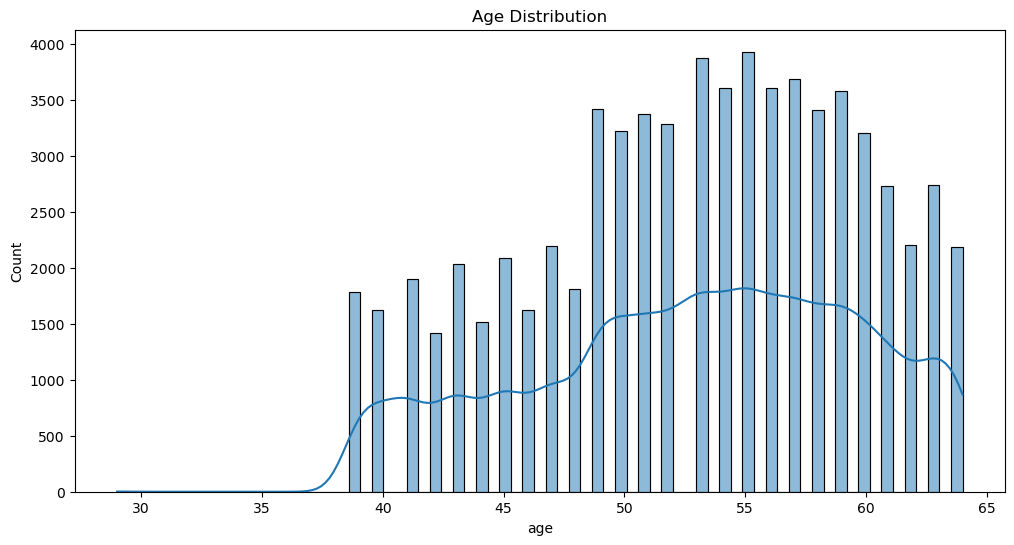

In [21]:
# Visualize the distribution of key features
plt.figure(figsize=(12,6))
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

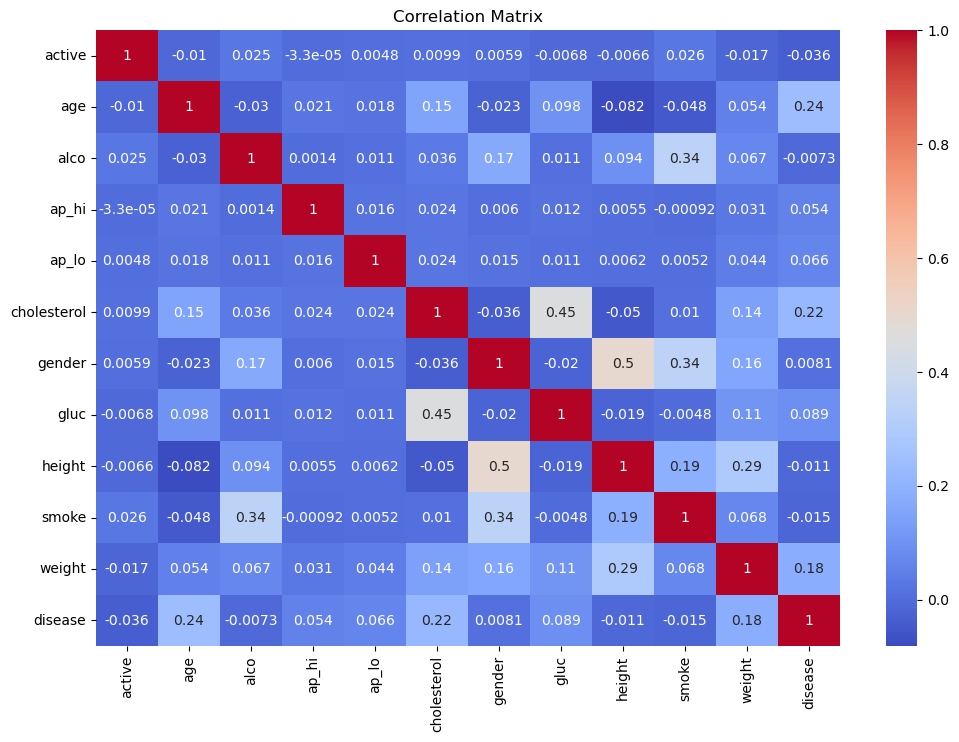

In [23]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


### Model Building

#### 1. Logistic Regression

In [27]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [29]:
# Predict on the test set
y_pred_log = log_reg.predict(X_test)

In [31]:
# Accuracy score for Logistic Regression
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy: {accuracy_log * 100:.2f}%")

Logistic Regression Accuracy: 72.27%


#### 2. Decision Tree

In [34]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [36]:
# Predict on the test set
y_pred_tree = tree.predict(X_test)

In [38]:
# Accuracy score for Decision Tree
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print(f"Decision Tree Accuracy: {accuracy_tree * 100:.2f}%")


Decision Tree Accuracy: 63.69%


#### 3. Support Vector Machine (SVM)

In [41]:
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [42]:
# Predict on the test set
y_pred_svm = svm.predict(X_test)

# Accuracy score for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%")


SVM Accuracy: 73.23%


### Model Evaluation

In [44]:
# Defining a custom function to call for the evaluation

def evaluate_model(y_test, y_pred, model_name):
    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

    # Classification Report
    print(f"{model_name} - Classification Report:")
    print(classification_report(y_test, y_pred))

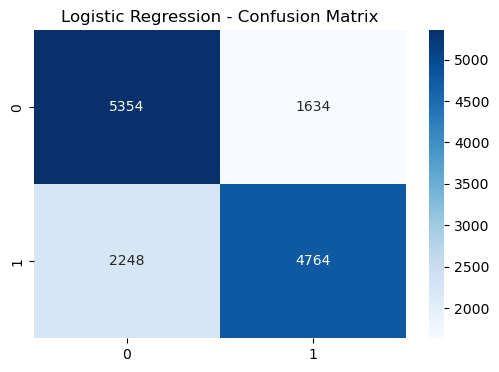

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.77      0.73      6988
           1       0.74      0.68      0.71      7012

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000



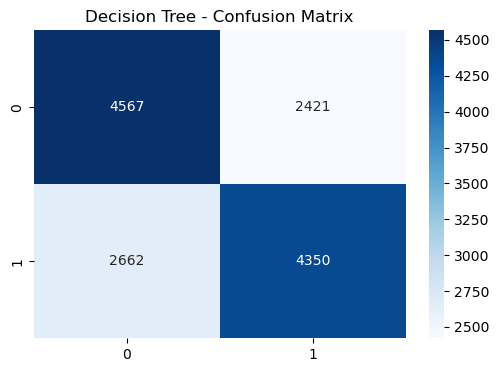

Decision Tree - Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.65      0.64      6988
           1       0.64      0.62      0.63      7012

    accuracy                           0.64     14000
   macro avg       0.64      0.64      0.64     14000
weighted avg       0.64      0.64      0.64     14000



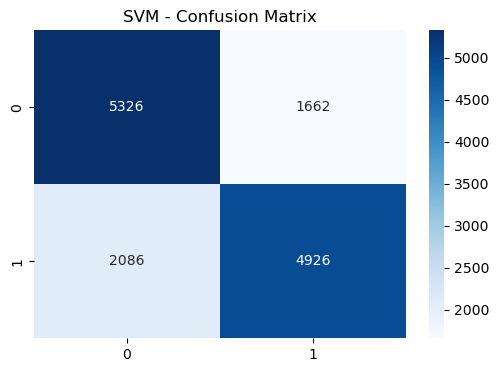

SVM - Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6988
           1       0.75      0.70      0.72      7012

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000



In [45]:
# Evaluate each model

evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_tree, "Decision Tree")
evaluate_model(y_test, y_pred_svm, "SVM")

### Hyperparameter Tuning with GridSearchCV

#### 1. Logistic Regression

In [48]:
param_grid_log = {'C': [0.1, 1, 10], 'solver': ['liblinear', 'saga']}
grid_log_reg = GridSearchCV(LogisticRegression(random_state=42), param_grid_log, cv=5, scoring='accuracy')
grid_log_reg.fit(X_train, y_train)

print(f"Best Logistic Regression Parameters: {grid_log_reg.best_params_}")
print(f"Best Logistic Regression Accuracy: {grid_log_reg.best_score_ * 100:.2f}%")


Best Logistic Regression Parameters: {'C': 10, 'solver': 'liblinear'}
Best Logistic Regression Accuracy: 71.92%


#### 2. Decision Tree

In [50]:
param_grid_tree = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5, scoring='accuracy')
grid_tree.fit(X_train, y_train)

print(f"Best Decision Tree Parameters: {grid_tree.best_params_}")
print(f"Best Decision Tree Accuracy: {grid_tree.best_score_ * 100:.2f}%")


Best Decision Tree Parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Decision Tree Accuracy: 72.83%


#### 3. SVM

In [52]:
# SVM Hyperparameter Tuning
param_grid_svm = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
grid_svm = GridSearchCV(SVC(random_state=42), param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_train, y_train)

print(f"Best SVM Parameters: {grid_svm.best_params_}")
print(f"Best SVM Accuracy: {grid_svm.best_score_ * 100:.2f}%")

# This code can take long to execute, if it takes too much time then interrupt the kernel and re execute.

In [64]:
import joblib

# Save the best Decision Tree model
joblib.dump(tree, "decision_heart_disease_model.pkl")

print("Decision model saved successfully!")

# print("Best Decision Tree model saved successfully!")


Decision model saved successfully!


In [62]:
import os
print(os.getcwd())


C:\Users\Naman jain\Documents\Machine Learning Project Solution\Project Solution
